<a href="https://colab.research.google.com/github/rahilkhan-acadmic/APAIML-GradedMiniProject/blob/develop/capstone/02_risk_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Model A — Visit Risk Classification
### Business Purpose: Predict whether a hospital visit represents a Low, Medium, or High operational and clinical risk.

   * Define the target variable as risk_score.
   *  Select and justify feature set based on business relevance.
   *  Perform a time-based train and test split (earliest 80 percent for training, latest 20 percent for testing).
   *  Train a baseline model using Logistic Regression.
   *  Train an advanced model such as Random Forest or Gradient Boosting.
   *  Perform optional hyperparameter tuning and document results.

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
# Upload file to google.colab
import io
from google.colab import files, drive

drive.mount('/content/drive')

# comment this code, if files already uploaded.
# uploaded = files.upload()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 1. Load data into Python for analysis. Combine them


In [33]:
# Load and read patients, visits & billing csv
patients_df = pd.read_csv('/content/drive/MyDrive/files/capstone/patients.csv')
patients_df.head()

visits_df = pd.read_csv('/content/drive/MyDrive/files/capstone/visits.csv')
visits_df.head()

billing_df = pd.read_csv('/content/drive/MyDrive/files/capstone/billing.csv')
billing_df.head()

,bill_id,visit_id,billed_amount,approved_amount,claim_status,payment_days,billing_date
0,1,1,23577.37,0.00,Rejected,16.0,2025-06-18
1,2,2,38178.81,38178.81,Paid,18.0,2025-10-09
2,3,3,5038.97,5038.97,Paid,NaN,2025-01-20
3,4,4,22813.34,22813.34,Paid,16.0,2025-12-24
4,5,5,27106.95,27106.95,Paid,14.0,2025-09-23


### 2. Analyze missing values in approved_amount, payment_days, and length_of_stay_hours.


In [34]:
# Analyze missing values in approved_amount, payment_days, and length_of_stay_hours.
df_merged = pd.merge(patients_df, visits_df, on='patient_id', how = 'inner')
df_merged = pd.merge(df_merged, billing_df, on='visit_id', how = 'inner')
df_merged.head()


,patient_id,age,gender,city,insurance_provider,chronic_flag,registration_date,visit_id,visit_date,department,visit_type,length_of_stay_hours,risk_score,doctor_id,bill_id,billed_amount,approved_amount,claim_status,payment_days,billing_date
0,1,53,M,Hyderabad,SecureLife,0,2025-05-14,4327,2025-10-15,General,ICU,6.39,High,162,4327,26322.05,13938.52,Pending,NaN,2025-11-29
1,1,53,M,Hyderabad,SecureLife,0,2025-05-14,5395,2025-09-21,Orthopedics,OPD,39.12,Low,181,5395,13258.56,0.00,Rejected,3.0,2025-08-15
2,1,53,M,Hyderabad,SecureLife,0,2025-05-14,9032,2025-02-09,Cardiology,OPD,19.57,Medium,121,9032,26555.09,26555.09,Paid,4.0,2025-12-31
3,1,53,M,Hyderabad,SecureLife,0,2025-05-14,9506,2025-10-09,Neurology,ER,30.32,Medium,135,9506,11583.16,8065.34,Pending,6.0,2025-01-30
4,1,53,M,Hyderabad,SecureLife,0,2025-05-14,10868,2025-07-07,ICU,ER,30.07,High,164,10868,9049.72,9049.72,Paid,19.0,2025-02-26


In [35]:
# Define the target variable as risk_score.
df_risk_score = df_merged[['risk_score']]
display(df_risk_score.head().reset_index())

,index,risk_score
0,0,High
1,1,Low
2,2,Medium
3,3,Medium
4,4,High


Index(['patient_id', 'age', 'gender', 'city', 'insurance_provider',
       'chronic_flag', 'registration_date', 'visit_id', 'visit_date',
       'department', 'visit_type', 'length_of_stay_hours', 'risk_score',
       'doctor_id', 'bill_id', 'billed_amount', 'approved_amount',
       'claim_status', 'payment_days', 'billing_date'],
      dtype='object')

,age,gender,city,insurance_provider,chronic_flag,department,visit_type,length_of_stay_hours,billed_amount,approved_amount,claim_status,payment_days
0,53,M,Hyderabad,SecureLife,0,General,ICU,6.39,26322.05,13938.52,Pending,NaN
1,53,M,Hyderabad,SecureLife,0,Orthopedics,OPD,39.12,13258.56,0.00,Rejected,3.0
2,53,M,Hyderabad,SecureLife,0,Cardiology,OPD,19.57,26555.09,26555.09,Paid,4.0
3,53,M,Hyderabad,SecureLife,0,Neurology,ER,30.32,11583.16,8065.34,Pending,6.0
4,53,M,Hyderabad,SecureLife,0,ICU,ER,30.07,9049.72,9049.72,Paid,19.0


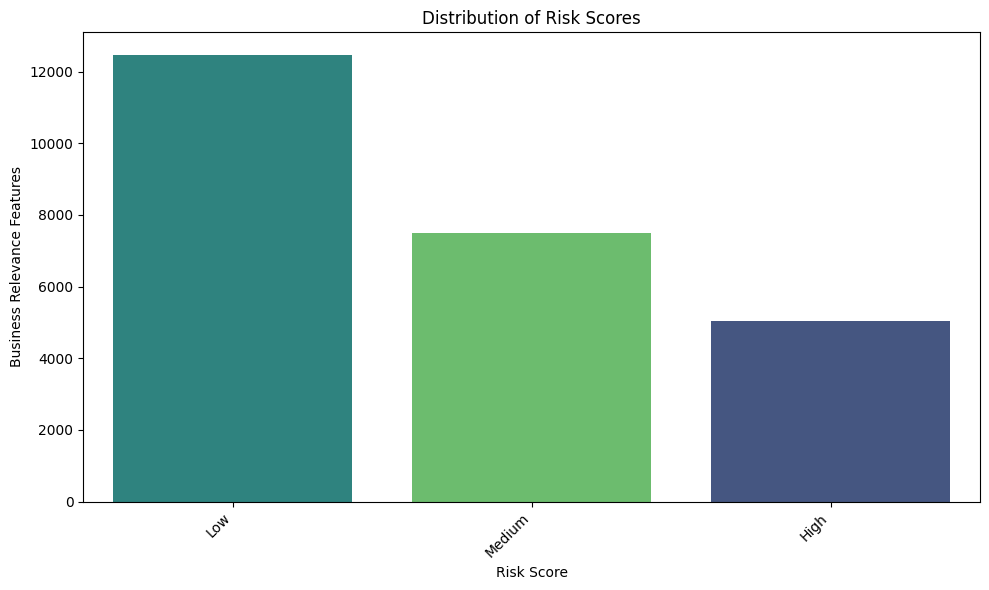

In [36]:
# Select and justify feature set based on business relevance.
display(df_merged.columns)
df_data = df_merged.drop(columns=['patient_id', 'visit_id', 'doctor_id', 'bill_id', 'registration_date', 'visit_date', 'billing_date','risk_score'])
display(df_data.head())

# distribution plot(countplot) of risk_score vs df_data
plt.figure(figsize=(10, 6))
sns.countplot(data=df_risk_score, x='risk_score', hue='risk_score', palette='viridis', legend=False, order=df_risk_score['risk_score'].value_counts().index)
plt.title('Distribution of Risk Scores')
plt.xlabel('Risk Score')
plt.ylabel('Business Relevance Features')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Reverted 'risk_score' to string labels for plotting.
Plotting Numerical Features against Risk Score:


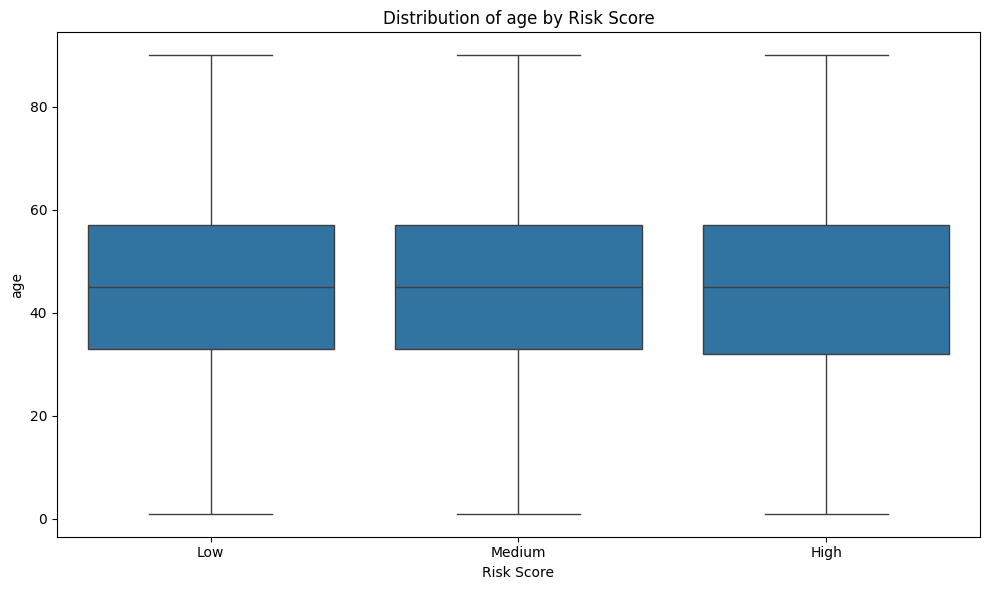

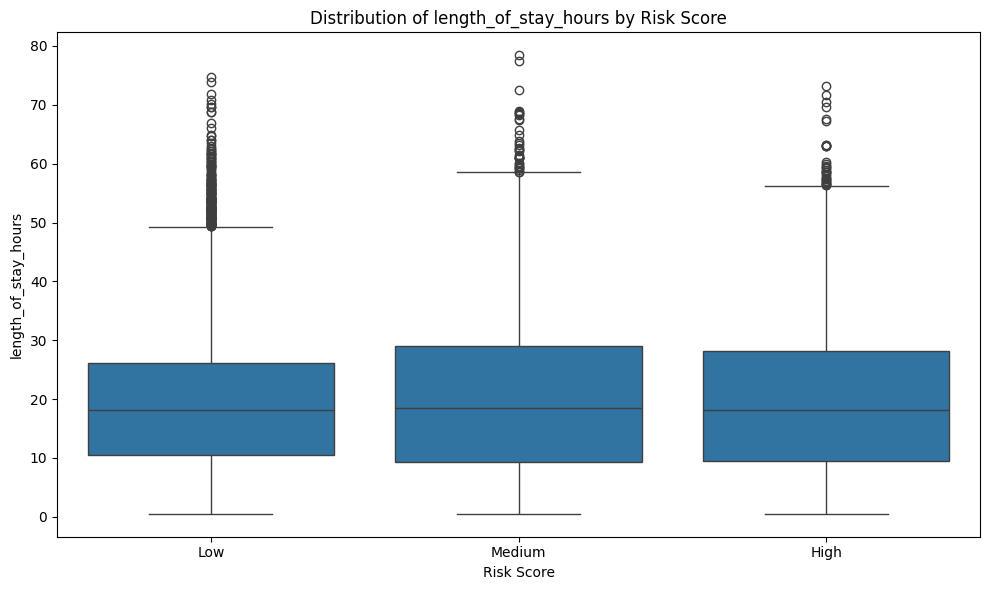

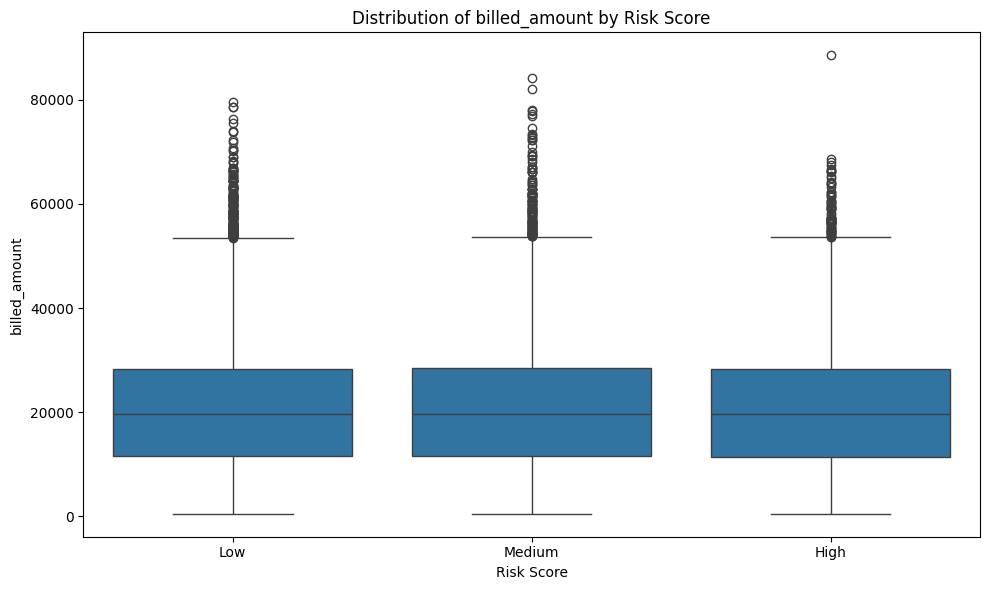

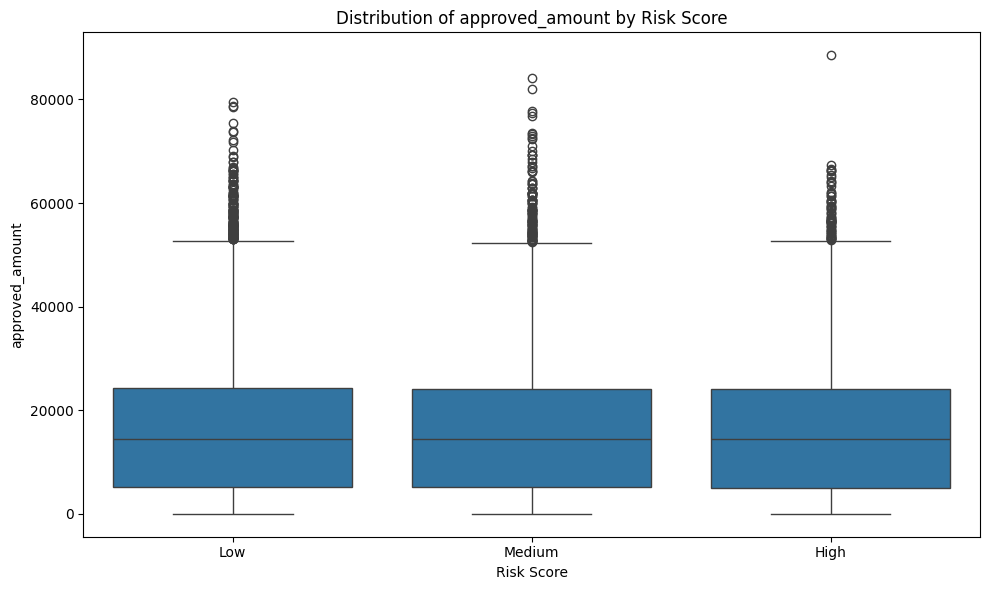

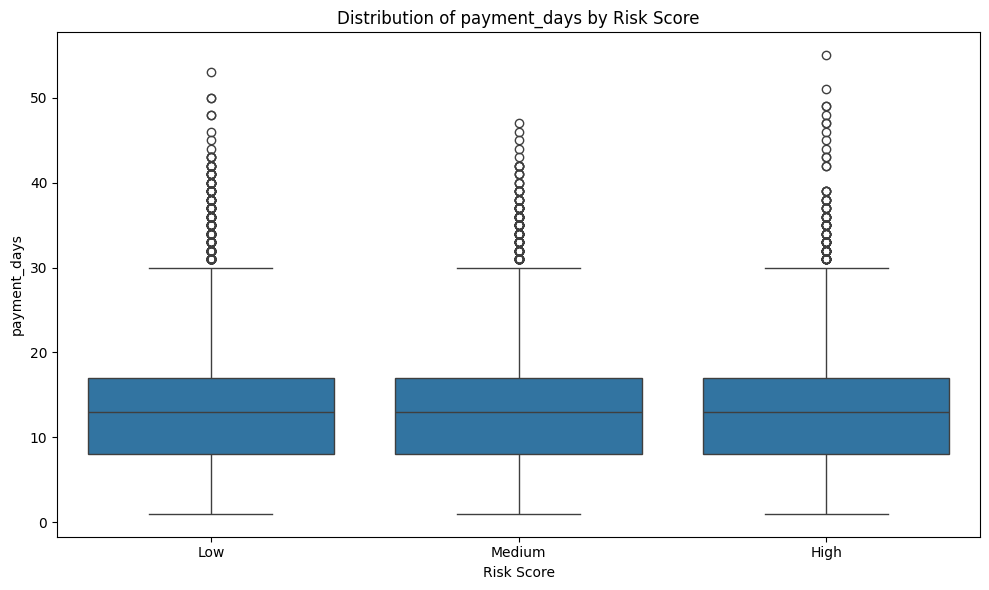

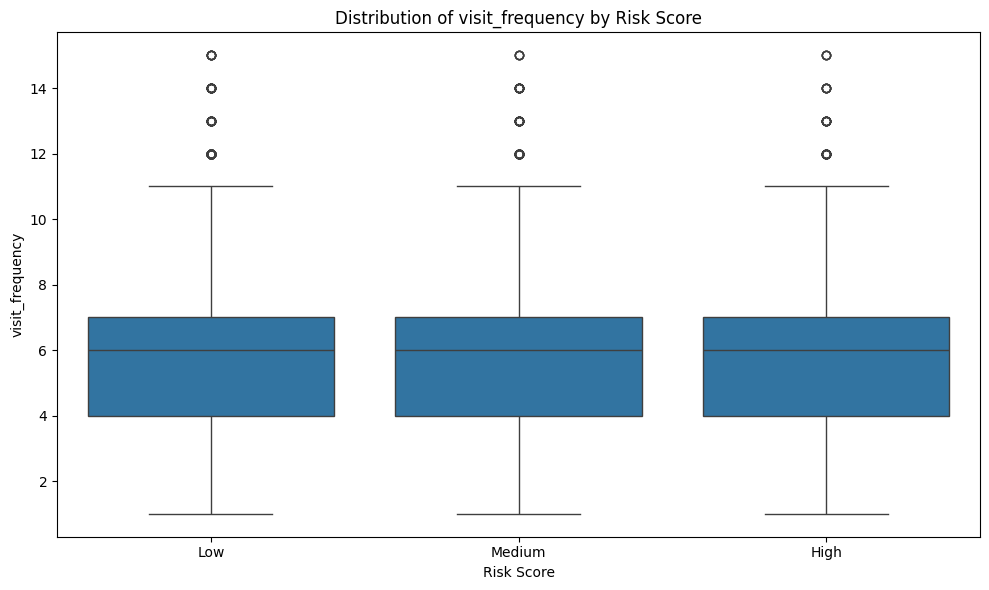

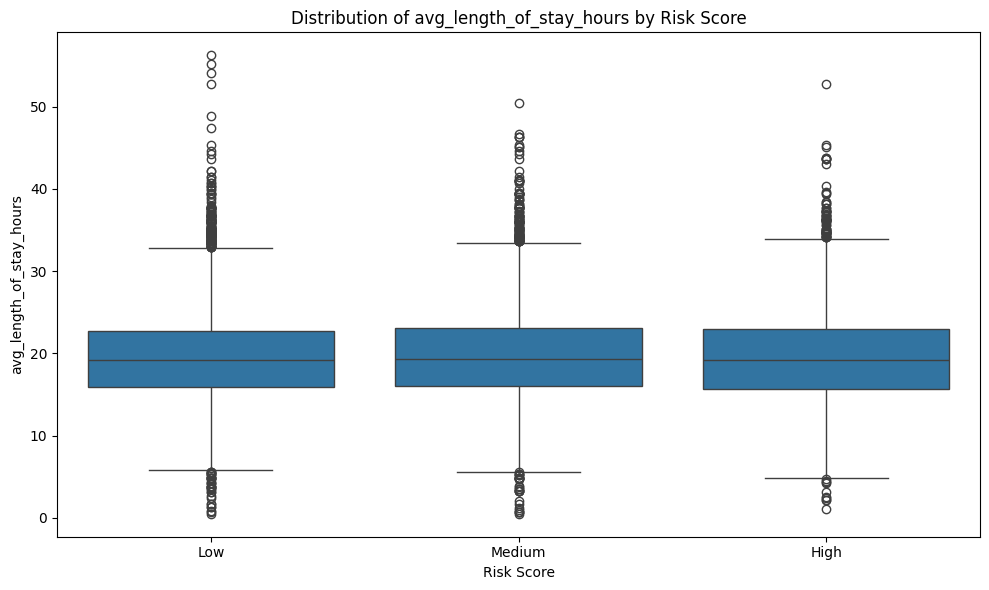

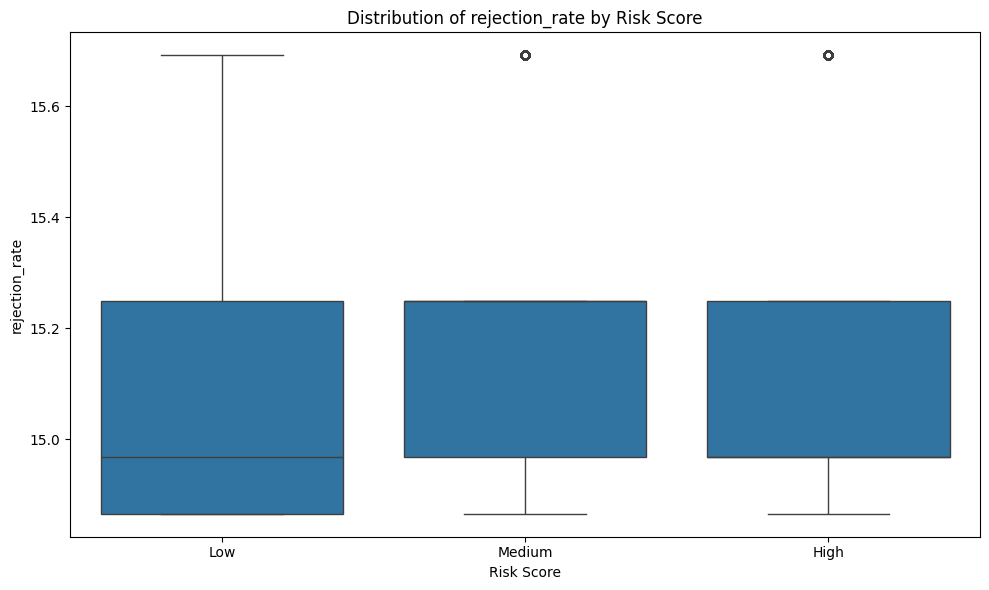

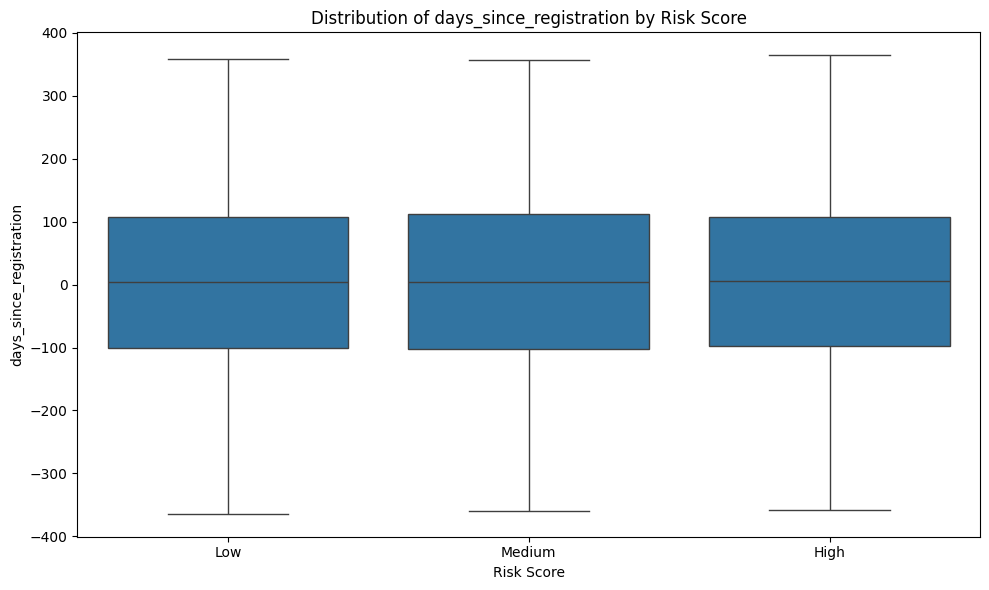

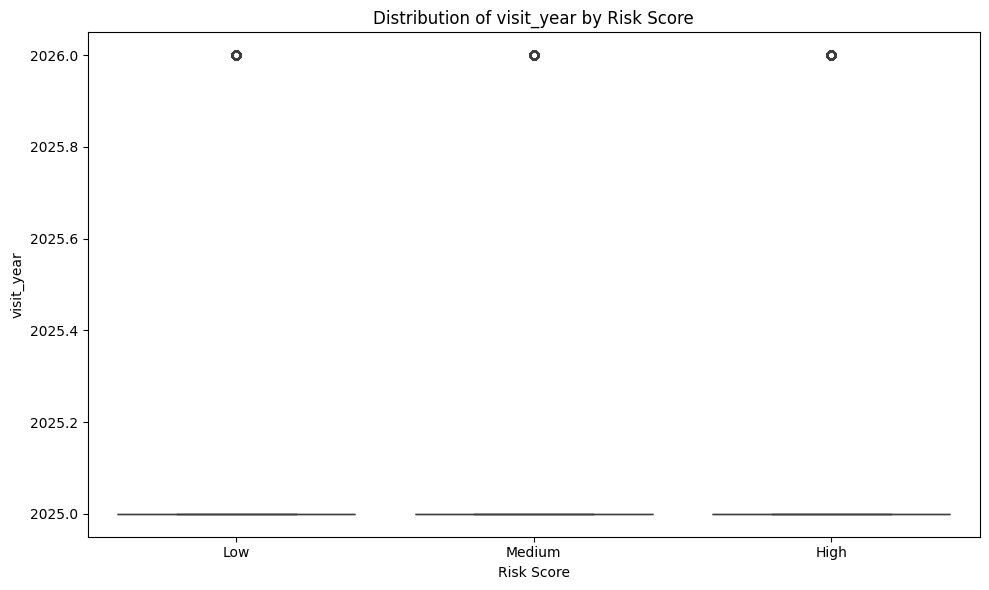

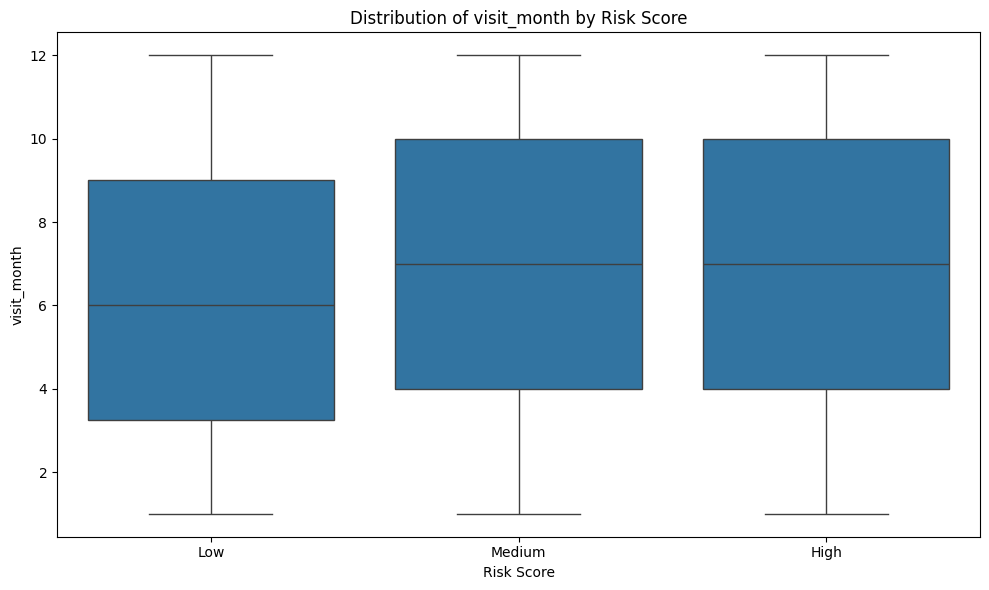

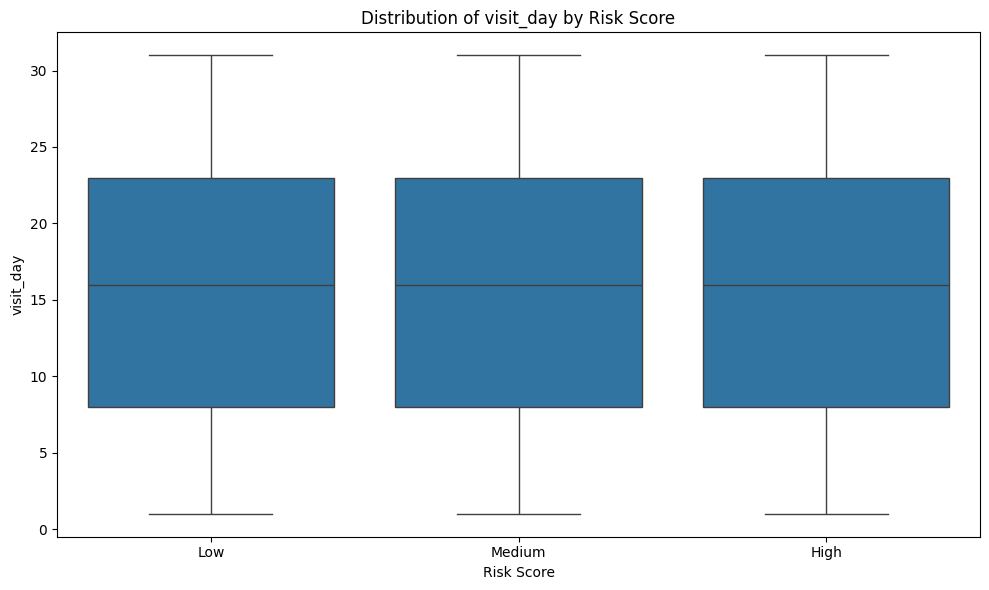

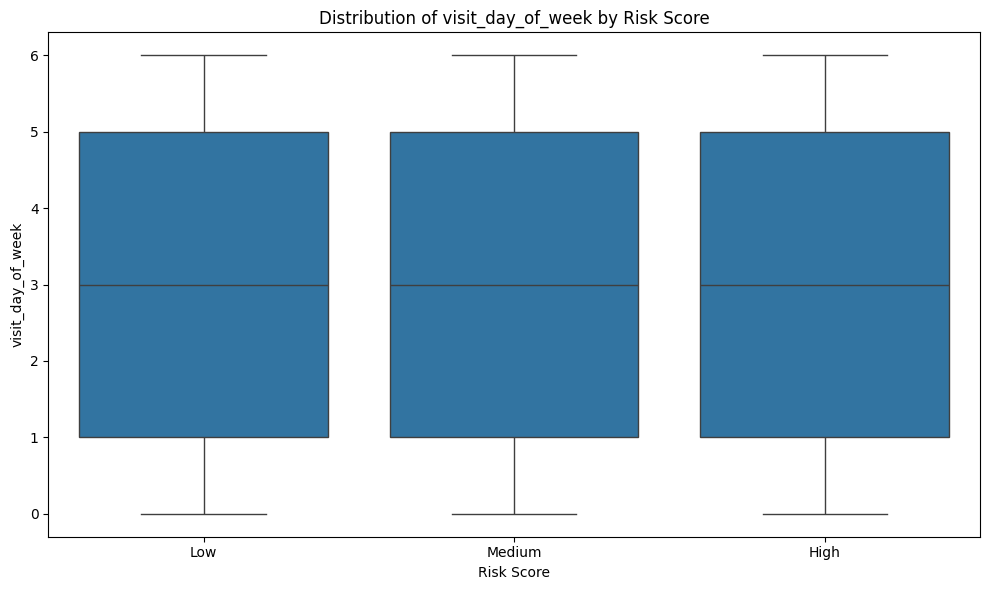

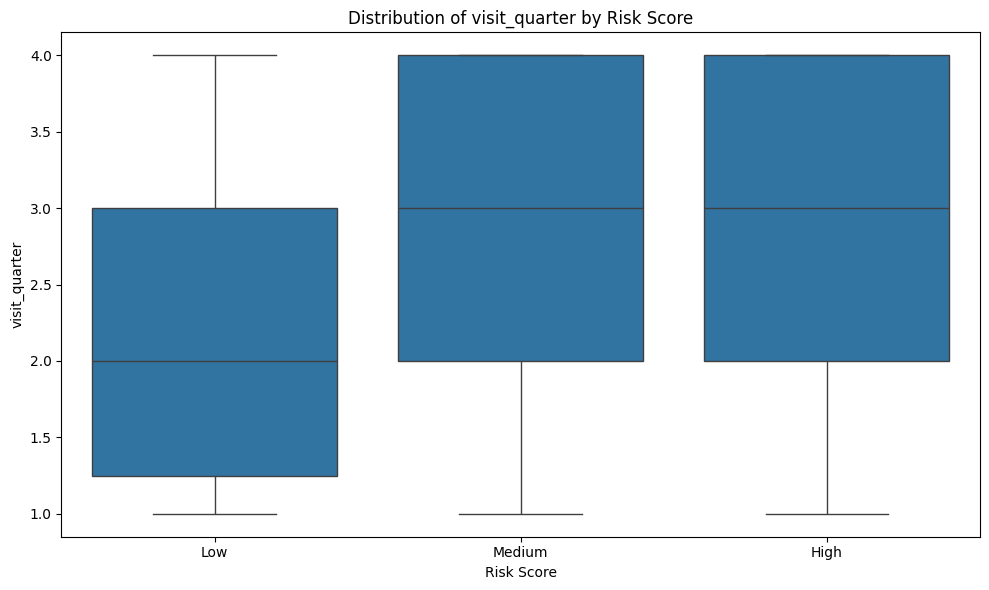

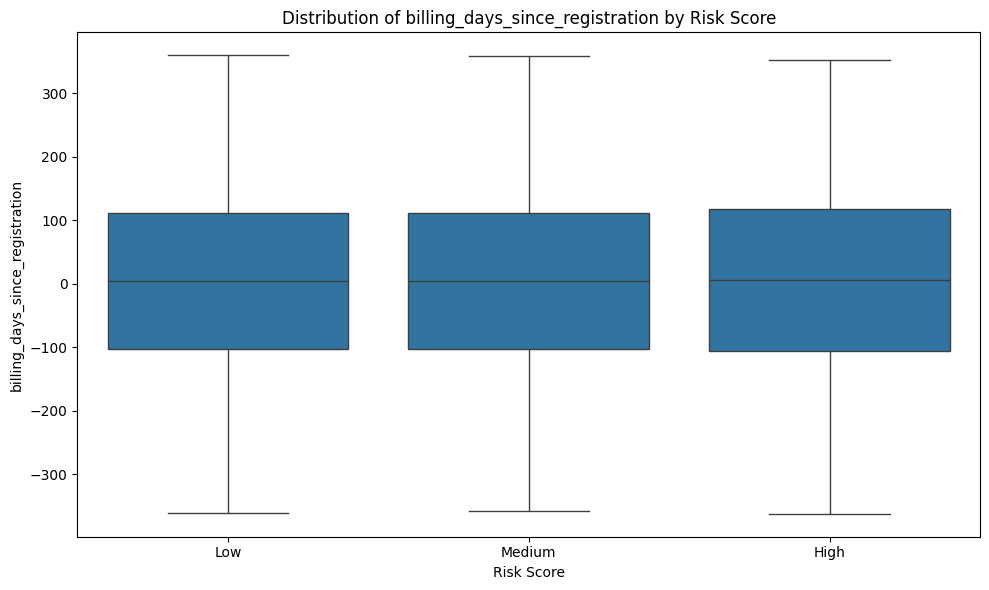


Plotting Categorical/Binary Features against Risk Score:


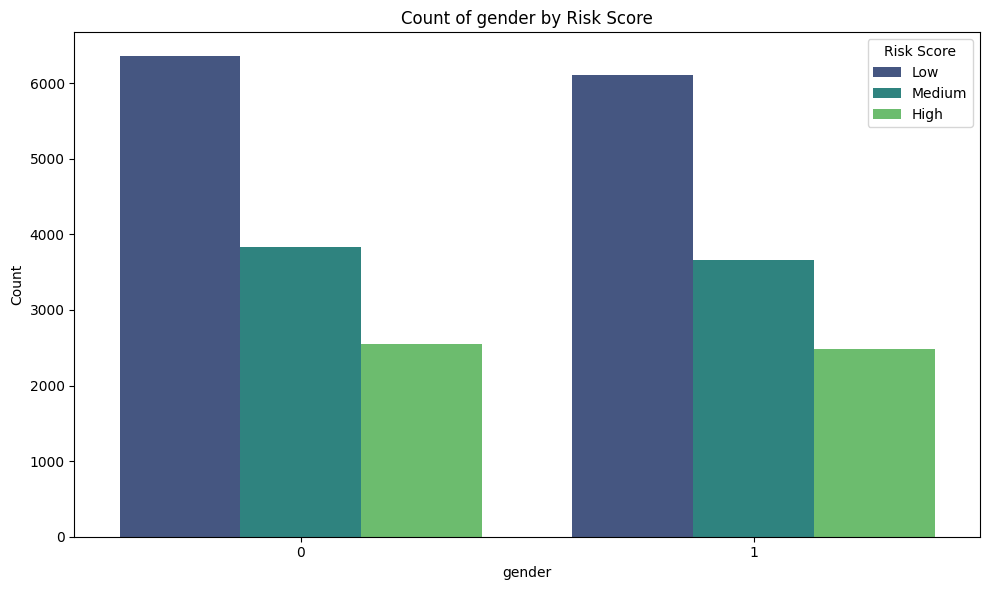

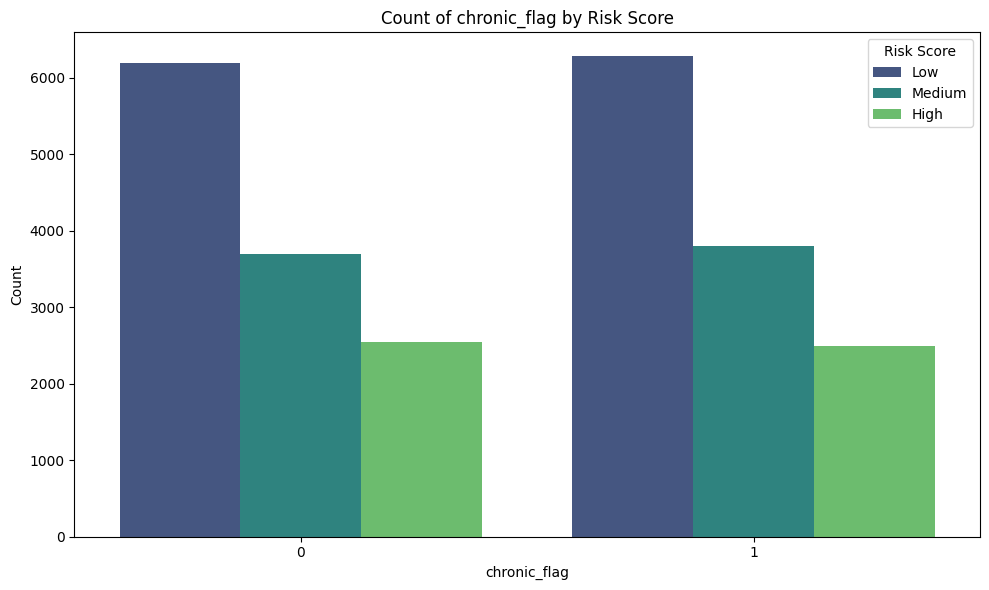

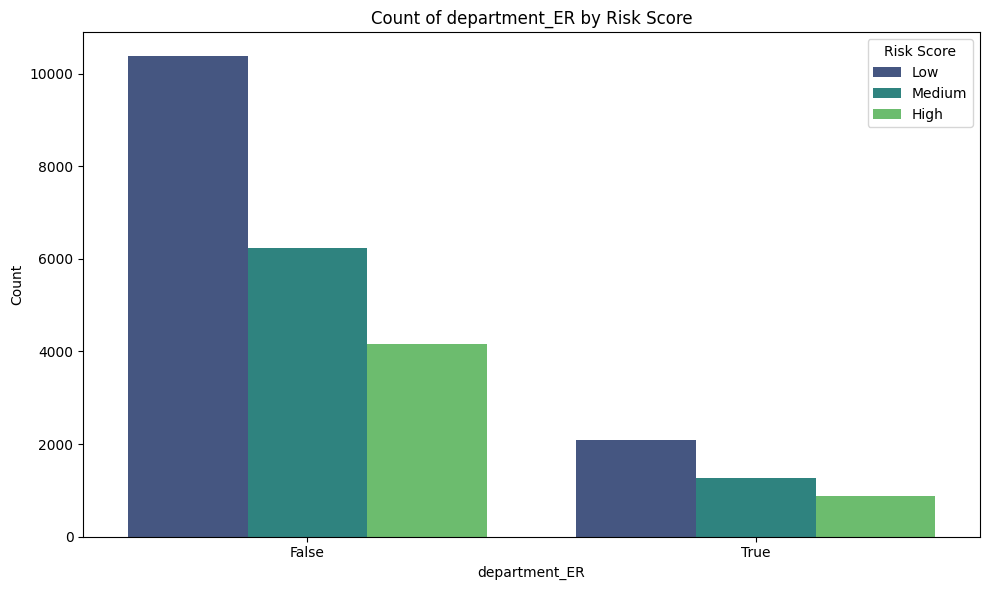

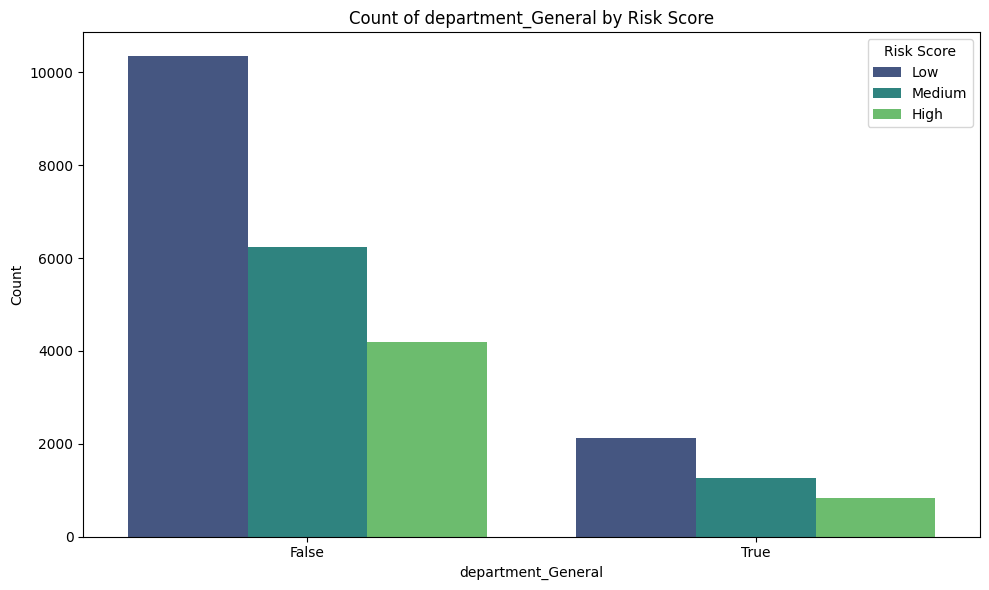

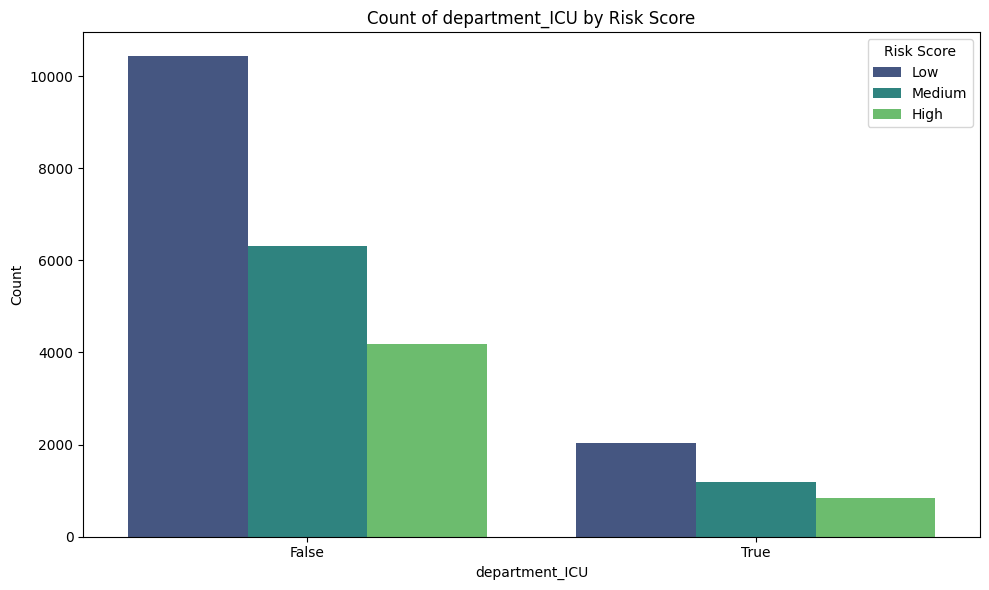

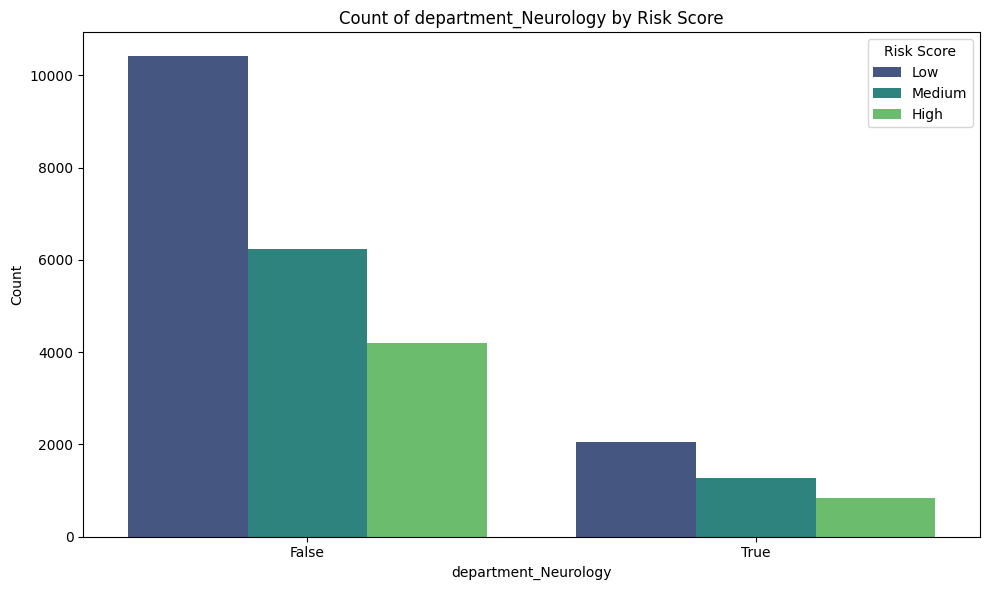

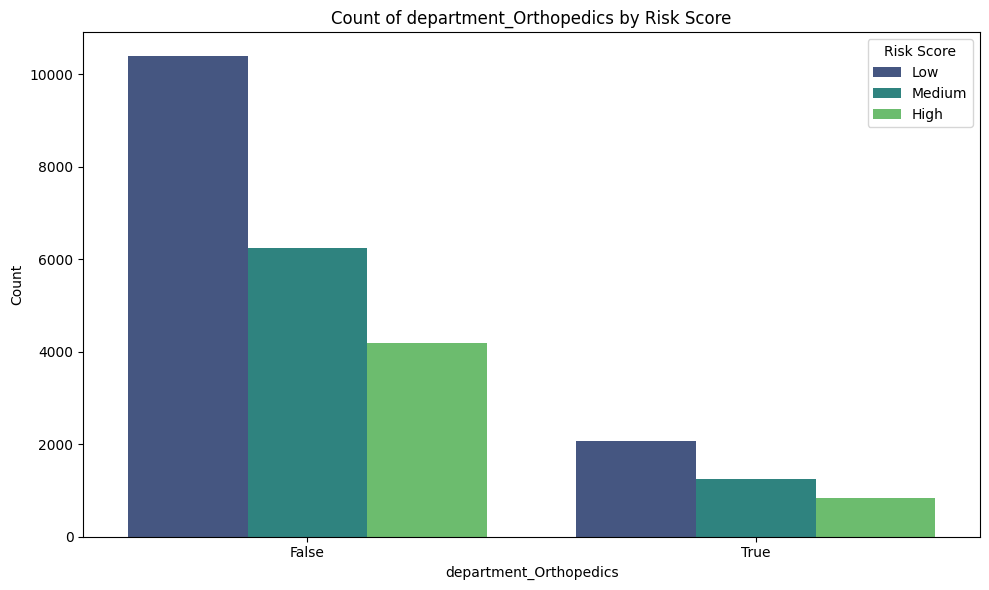

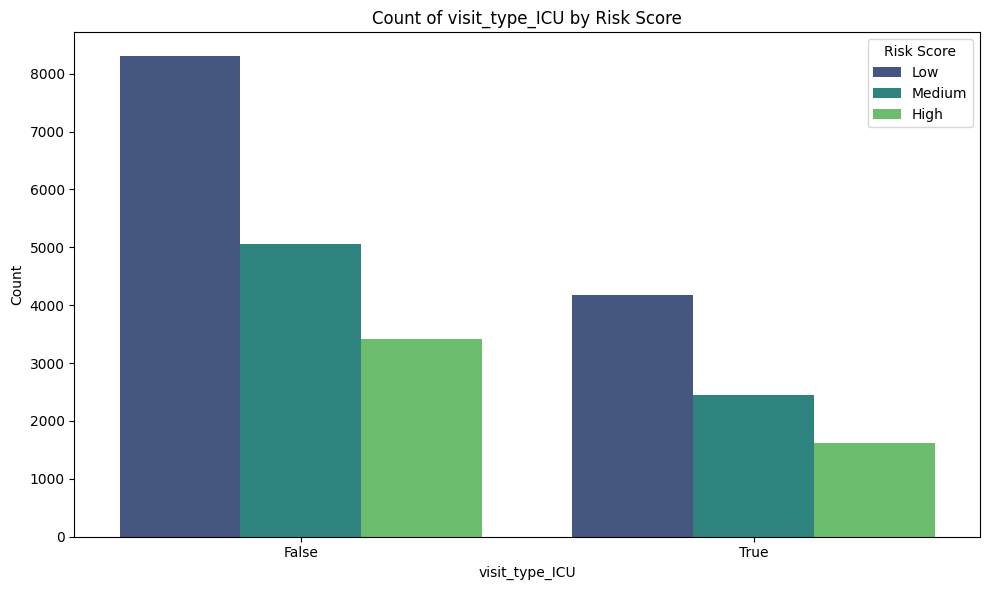

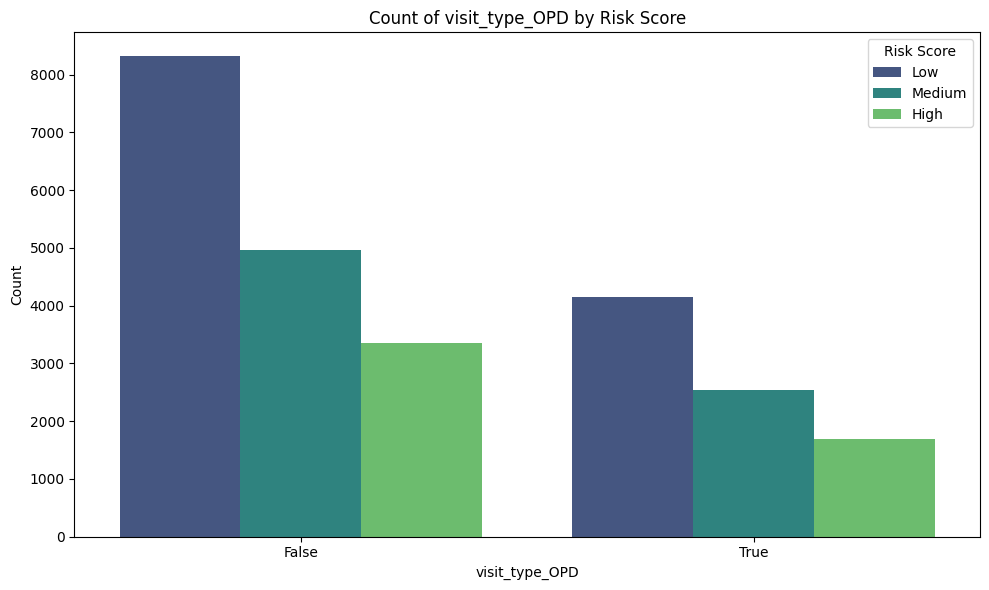

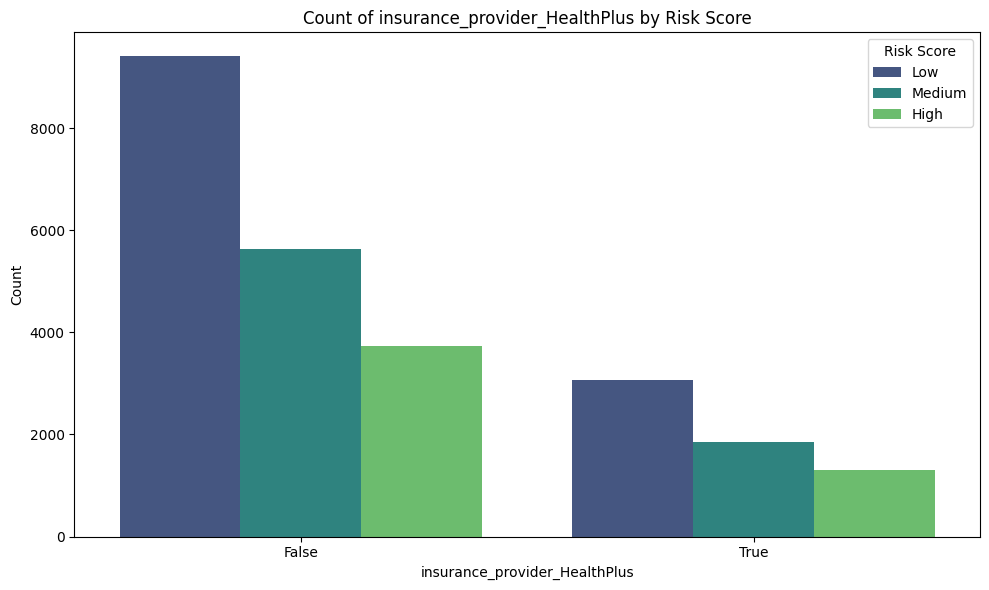

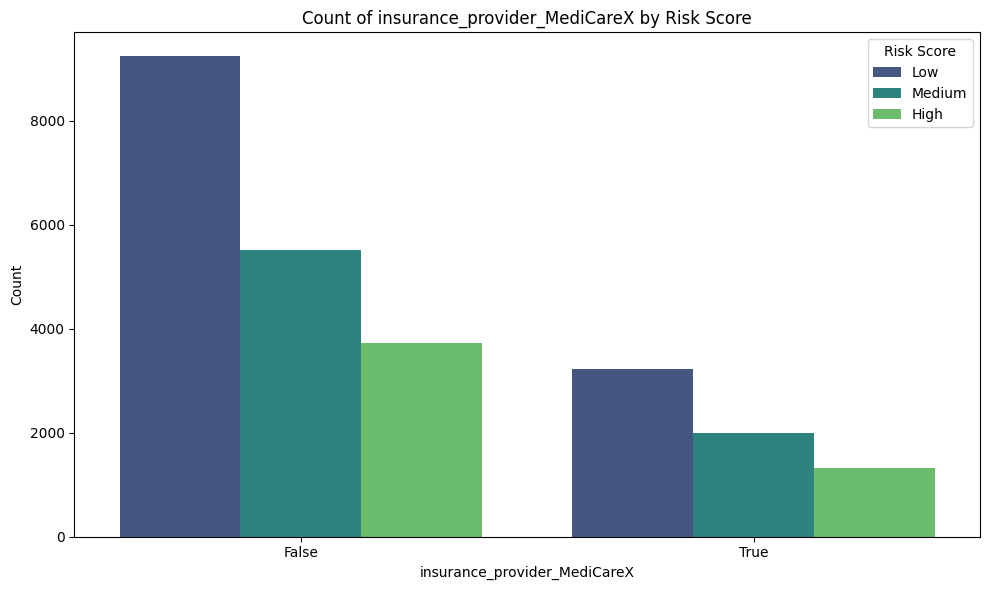

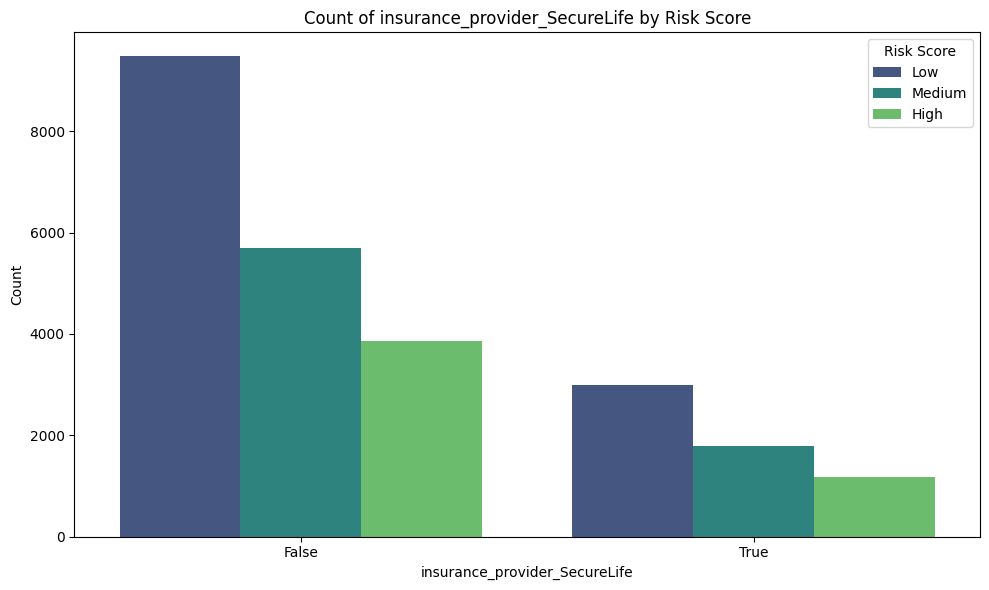

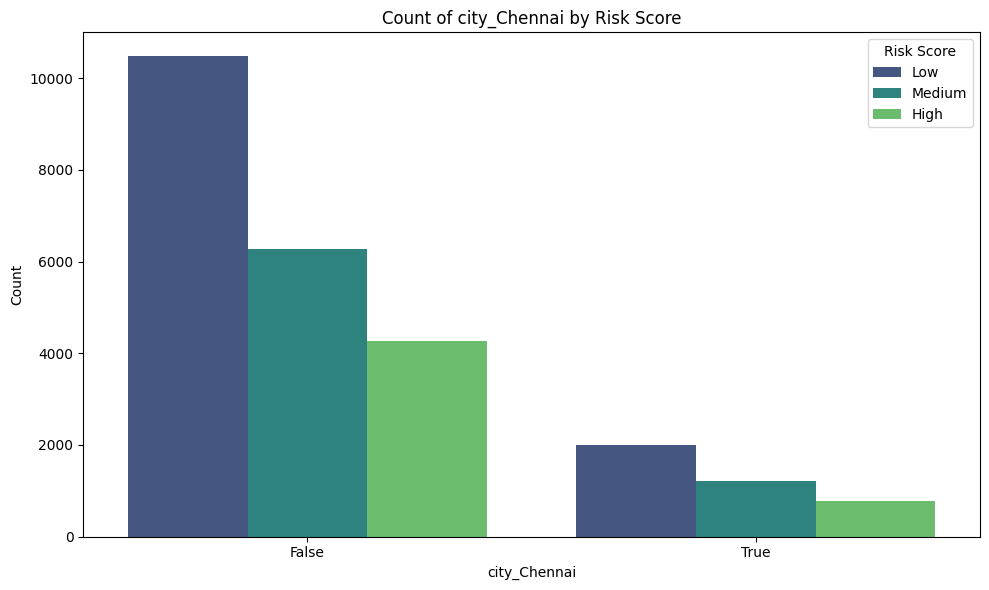

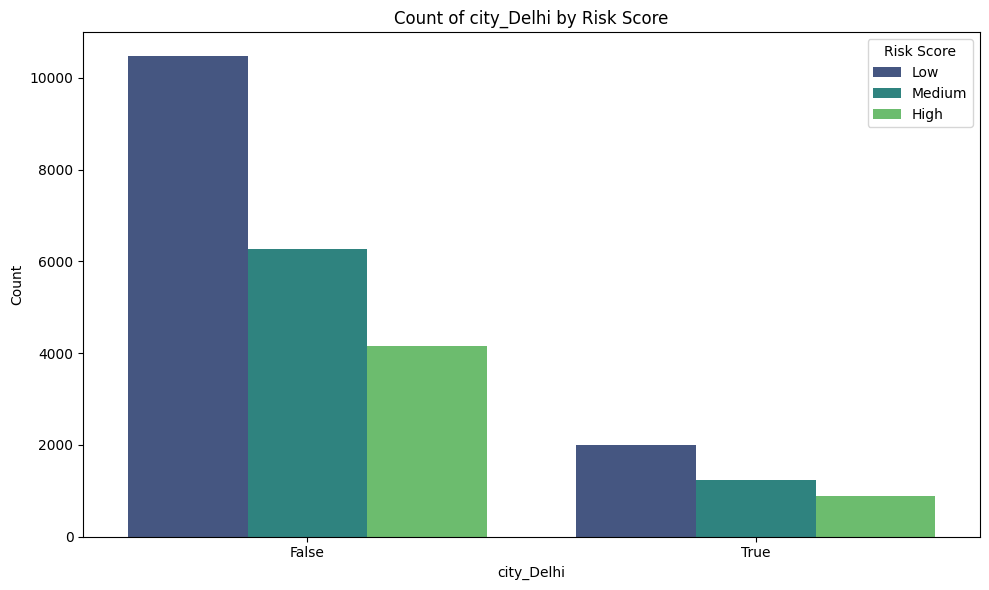

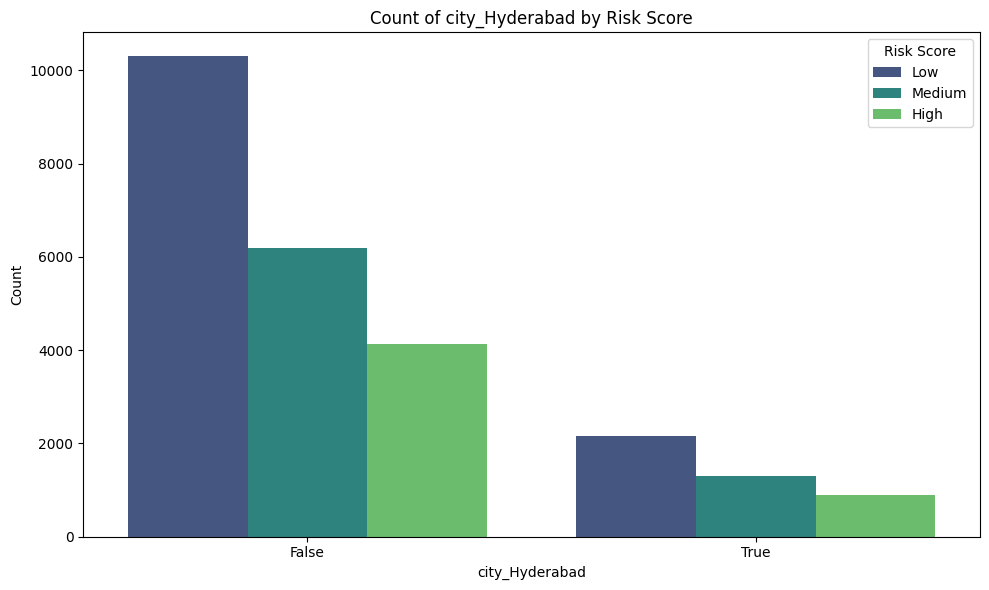

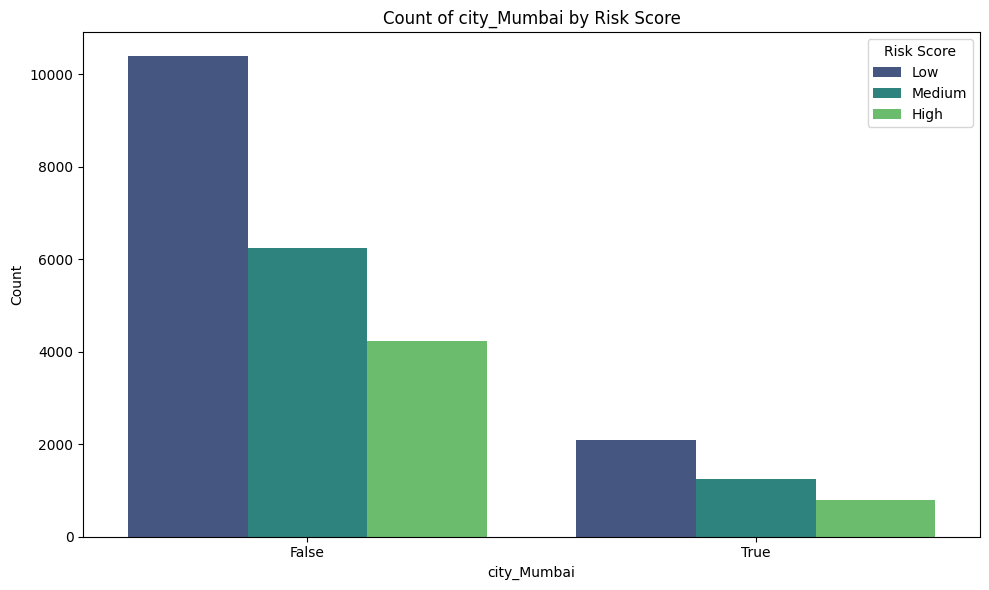

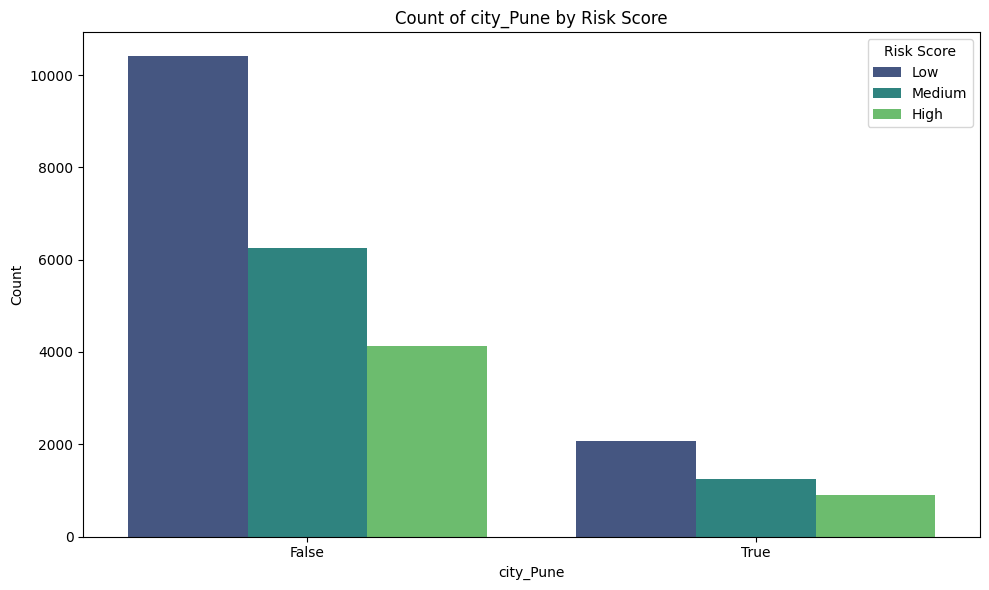

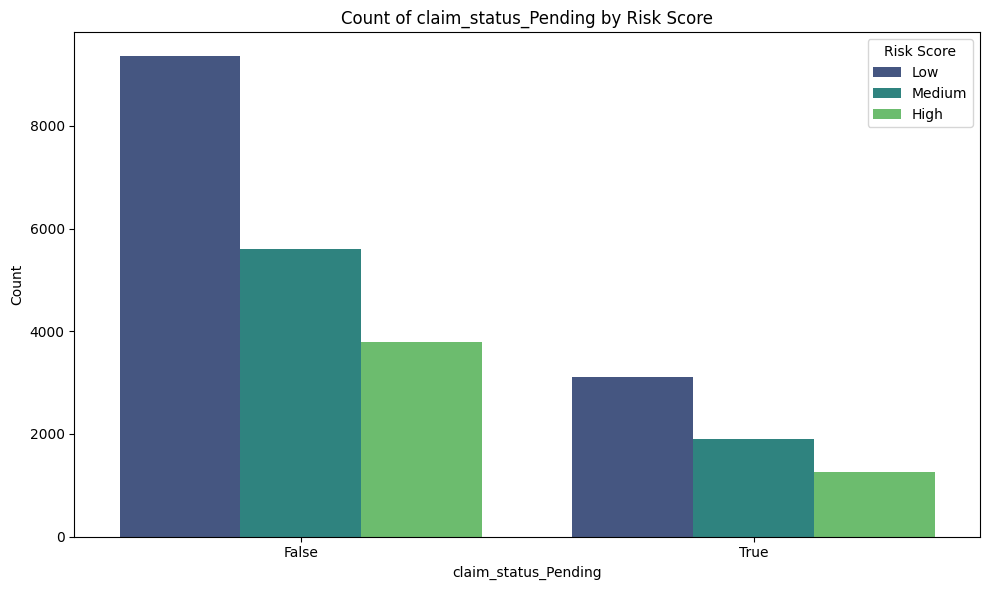

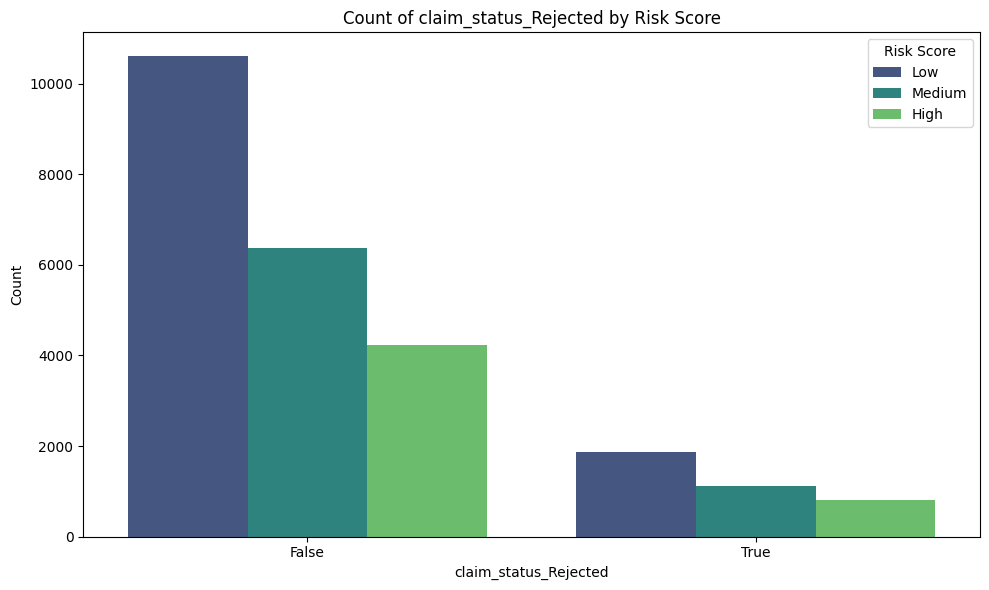

In [57]:
# Distribution plot of risk_score against each element in df_data

# Check if risk_score is numeric (meaning it has been encoded)
# and convert back to string labels for plotting consistency with risk_score_order
if pd.api.types.is_numeric_dtype(df_merged['risk_score']):
    inverse_risk_score_mapping = {0: 'Low', 1: 'Medium', 2: 'High'}
    df_merged['risk_score'] = df_merged['risk_score'].map(inverse_risk_score_mapping)
    print("Reverted 'risk_score' to string labels for plotting.")

# Define numerical and categorical columns that are part of df_data
numerical_cols = ['age', 'length_of_stay_hours', 'billed_amount', 'approved_amount', 'payment_days',
                  'visit_frequency', 'avg_length_of_stay_hours', 'rejection_rate', 'days_since_registration',
                  'visit_year', 'visit_month', 'visit_day', 'visit_day_of_week', 'visit_quarter',
                  'billing_days_since_registration']

categorical_cols = ['gender', 'chronic_flag', 'department_ER', 'department_General', 'department_ICU',
                    'department_Neurology', 'department_Orthopedics', 'visit_type_ICU', 'visit_type_OPD',
                    'insurance_provider_HealthPlus', 'insurance_provider_MediCareX', 'insurance_provider_SecureLife',
                    'city_Chennai', 'city_Delhi', 'city_Hyderabad', 'city_Mumbai', 'city_Pune',
                    'claim_status_Pending', 'claim_status_Rejected']

# Order for risk_score for consistent plotting
risk_score_order = ['Low', 'Medium', 'High']

# Plotting numerical features against risk_score using boxplots
print("Plotting Numerical Features against Risk Score:")
for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='risk_score', y=col, data=df_merged, order=risk_score_order, fill=True)
    plt.title(f'Distribution of {col} by Risk Score')
    plt.xlabel('Risk Score')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

# Plotting categorical/binary features against risk_score using countplots
print("\nPlotting Categorical/Binary Features against Risk Score:")
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(x=col, hue='risk_score', data=df_merged, palette='viridis', hue_order=risk_score_order)
    plt.title(f'Count of {col} by Risk Score')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.legend(title='Risk Score')
    plt.tight_layout()
    plt.show()